<a href="https://colab.research.google.com/github/Ruiyang1210W/PoseHelper/blob/main/notebooks/Pose_Helper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow -q
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# Load MoveNet Thunder (high accuracy)
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures['serving_default']
print("MoveNet model loaded")

# Load your image
img = cv2.imread("/content/test_pose.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess for MoveNet (requires 256x256)
input_img = tf.image.resize_with_pad(
    tf.expand_dims(img_rgb, axis=0), 256, 256)
input_img = tf.cast(input_img, dtype=tf.int32)

# Run inference
outputs = movenet(input_img)
keypoints = outputs['output_0'].numpy()[0][0]  # shape: (17, 3)

# Print keypoints
KEYPOINT_NAMES = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]

print(f"\n Pose detected! 17 keypoints:")
for i, (name, kp) in enumerate(zip(KEYPOINT_NAMES, keypoints)):
    y, x, confidence = kp
    print(f"  {i:02d} {name:20s}: x={x:.3f}, y={y:.3f}, confidence={confidence:.3f}")

TensorFlow version: 2.20.0
MoveNet model loaded

 Pose detected! 17 keypoints:
  00 nose                : x=0.483, y=0.249, confidence=0.605
  01 left_eye            : x=0.487, y=0.231, confidence=0.724
  02 right_eye           : x=0.482, y=0.235, confidence=0.698
  03 left_ear            : x=0.521, y=0.204, confidence=0.729
  04 right_ear           : x=0.506, y=0.215, confidence=0.482
  05 left_shoulder       : x=0.596, y=0.221, confidence=0.856
  06 right_shoulder      : x=0.482, y=0.275, confidence=0.715
  07 left_elbow          : x=0.667, y=0.156, confidence=0.700
  08 right_elbow         : x=0.391, y=0.292, confidence=0.760
  09 left_wrist          : x=0.654, y=0.071, confidence=0.768
  10 right_wrist         : x=0.420, y=0.206, confidence=0.554
  11 left_hip            : x=0.535, y=0.484, confidence=0.869
  12 right_hip           : x=0.456, y=0.477, confidence=0.659
  13 left_knee           : x=0.562, y=0.664, confidence=0.883
  14 right_knee          : x=0.425, y=0.654, confiden

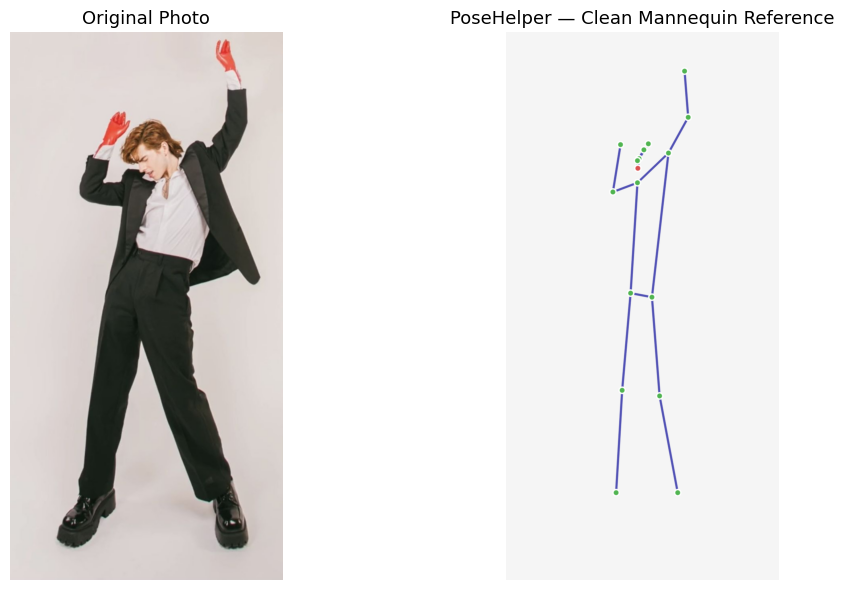

Mannequin rendered and saved as posehelper_output.png


In [3]:
# Draw clean mannequin skeleton on a blank canvas
KEYPOINT_NAMES = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]

# Skeleton connections [from, to]
CONNECTIONS = [
    (0, 1), (0, 2),           # nose → eyes
    (1, 3), (2, 4),           # eyes → ears
    (5, 6),                   # shoulders
    (5, 7), (7, 9),           # left arm
    (6, 8), (8, 10),          # right arm
    (5, 11), (6, 12),         # torso
    (11, 12),                 # hips
    (11, 13), (13, 15),       # left leg
    (12, 14), (14, 16),       # right leg
]

# Canvas size
h, w = img_rgb.shape[:2]
canvas = np.ones((h, w, 3), dtype=np.uint8) * 245  # light gray background

# Scale keypoints to image size
CONFIDENCE_THRESHOLD = 0.15
kp_coords = []
for kp in keypoints:
    y, x, conf = kp
    kp_coords.append((int(x * w), int(y * h), conf))

# Draw connections (limbs)
for (i, j) in CONNECTIONS:
    x1, y1, c1 = kp_coords[i]
    x2, y2, c2 = kp_coords[j]
    if c1 > CONFIDENCE_THRESHOLD and c2 > CONFIDENCE_THRESHOLD:
        cv2.line(canvas, (x1, y1), (x2, y2), (80, 80, 180), 4, cv2.LINE_AA)

# Draw joints
for idx, (x, y, conf) in enumerate(kp_coords):
    if conf > CONFIDENCE_THRESHOLD:
        color = (220, 80, 80) if idx == 0 else (80, 180, 80)  # red for nose, green for rest
        cv2.circle(canvas, (x, y), 8, color, -1, cv2.LINE_AA)
        cv2.circle(canvas, (x, y), 8, (255, 255, 255), 2, cv2.LINE_AA)  # white outline

# Show side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Photo", fontsize=13)
axes[0].axis('off')
axes[1].imshow(canvas)
axes[1].set_title("PoseHelper — Clean Mannequin Reference", fontsize=13)
axes[1].axis('off')
plt.tight_layout()
plt.savefig("posehelper_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("Mannequin rendered and saved as posehelper_output.png")



In [5]:
import zipfile, os

with zipfile.ZipFile("/content/archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/yoga_poses")
print("Unzipped!")

# Check structure
for root, dirs, files in os.walk("/content/yoga_poses"):
    level = root.replace("/content/yoga_poses", '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for file in list(files)[:2]:
            print(f'{subindent}{file}')

Unzipped!
yoga_poses/
  DATASET/
    TRAIN/
    TEST/


In [6]:
import csv
from tqdm import tqdm

# Setup
TRAIN_DIR = "/content/yoga_poses/DATASET/TRAIN"
pose_classes = sorted(os.listdir(TRAIN_DIR))
print(f"Found {len(pose_classes)} pose classes: {pose_classes}")

def extract_keypoints(image_path):
    """Run MoveNet on one image, return 51-dim keypoint vector or None."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_img = tf.image.resize_with_pad(
        tf.expand_dims(img_rgb, axis=0), 256, 256)
    input_img = tf.cast(input_img, dtype=tf.int32)
    outputs = movenet(input_img)
    keypoints = outputs['output_0'].numpy()[0][0]  # (17, 3)
    return keypoints.flatten()  # 51-dim vector

# Extract keypoints from all training images
rows = []
skipped = 0

for label in pose_classes:
    folder = os.path.join(TRAIN_DIR, label)
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"  Processing {label}: {len(images)} images...")

    for fname in tqdm(images, desc=label, leave=False):
        fpath = os.path.join(folder, fname)
        kp = extract_keypoints(fpath)
        if kp is not None:
            rows.append(list(kp) + [label])
        else:
            skipped += 1

# Save to CSV
KEYPOINT_NAMES = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]
header = []
for name in KEYPOINT_NAMES:
    header += [f'{name}_y', f'{name}_x', f'{name}_conf']
header += ['label']

csv_path = "/content/yoga_keypoints.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print(f"\n Done! {len(rows)} samples saved, {skipped} skipped")
print(f" CSV saved to {csv_path}")


Found 5 pose classes: ['downdog', 'goddess', 'plank', 'tree', 'warrior2']
  Processing downdog: 222 images...


  Processing goddess: 180 images...


  Processing plank: 266 images...


  Processing tree: 160 images...


  Processing warrior2: 252 images...



 Done! 1080 samples saved, 0 skipped
 CSV saved to /content/yoga_keypoints.csv


Loaded 1080 samples, 52 columns
   Class distribution:
label
plank       266
warrior2    252
downdog     222
goddess     180
tree        160
Name: count, dtype: int64

Train: 864 samples | Test: 216 samples

  Logistic Regression       → Accuracy: 85.2%
  K-Nearest Neighbors       → Accuracy: 81.9%
  MLP Classifier            → Accuracy: 85.2%

 Best model: Logistic Regression (85.2%)

Classification Report (Best Model):
              precision    recall  f1-score   support

     downdog       0.98      0.96      0.97        45
     goddess       0.84      0.75      0.79        36
       plank       0.79      0.94      0.86        53
        tree       0.90      0.84      0.87        32
    warrior2       0.79      0.74      0.76        50

    accuracy                           0.85       216
   macro avg       0.86      0.85      0.85       216
weighted avg       0.85      0.85      0.85       216



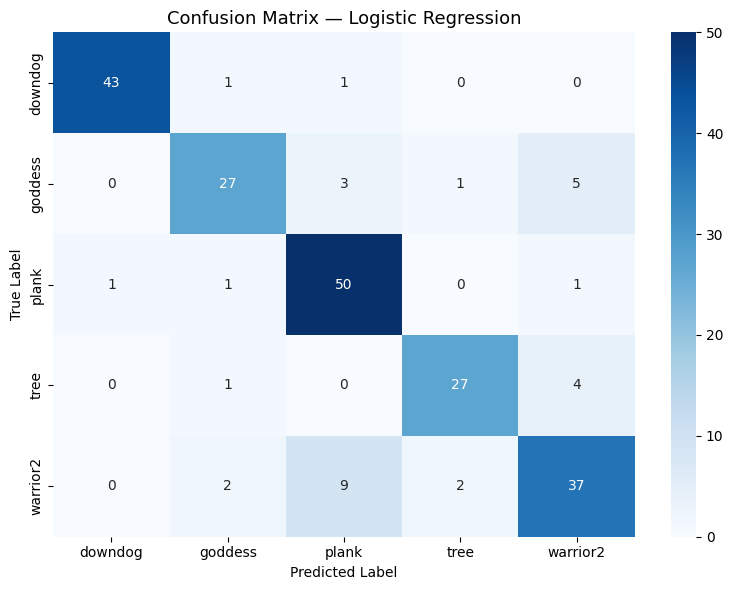

 Confusion matrix saved


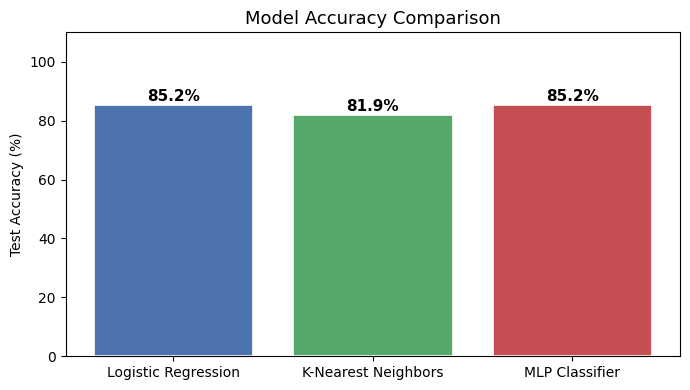

 Accuracy chart saved


In [7]:
# train the classifiers
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load CSV ─────────────────────────────────────────────────────────────
df = pd.read_csv("/content/yoga_keypoints.csv")
print(f"Loaded {len(df)} samples, {df.shape[1]} columns")
print(f"   Class distribution:\n{df['label'].value_counts()}\n")

X = df.drop('label', axis=1).values
y = df['label'].values

# ── Train/test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples\n")

# ── Train 3 models ───────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'MLP Classifier':      MLPClassifier(hidden_layer_sizes=(64, 32),
                                         max_iter=500, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    acc = model.score(X_test_s, y_test)
    results[name] = acc
    print(f"  {name:25s} → Accuracy: {acc*100:.1f}%")

best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\n Best model: {best_name} ({results[best_name]*100:.1f}%)")

# ── Classification report ────────────────────────────────────────────────
print("\nClassification Report (Best Model):")
y_pred = best_model.predict(X_test_s)
print(classification_report(y_test, y_pred))

# ── Confusion matrix plot ────────────────────────────────────────────────
classes = sorted(df['label'].unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()
print(" Confusion matrix saved")

# ── Accuracy comparison bar chart ───────────────────────────────────────
plt.figure(figsize=(7, 4))
names = list(results.keys())
accs  = [v * 100 for v in results.values()]
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(names, accs, color=colors, edgecolor='white', linewidth=1.2)
plt.ylim(0, 110)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=13)
plt.ylabel('Test Accuracy (%)')
plt.tight_layout()
plt.savefig("/content/accuracy_comparison.png", dpi=150)
plt.show()
print(" Accuracy chart saved")

In [8]:
# save MLP
import pickle
from google.colab import files

# Save best model and scaler
with open("/content/mlp_classifier.pkl", "wb") as f:
    pickle.dump(models['MLP Classifier'], f)

with open("/content/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label classes
import json
classes = sorted(df['label'].unique().tolist())
with open("/content/classes.json", "w") as f:
    json.dump(classes, f)

print("Saved:")
print(f"   Classes: {classes}")

files.download("/content/mlp_classifier.pkl")
files.download("/content/scaler.pkl")
files.download("/content/classes.json")
files.download("/content/yoga_keypoints.csv")

Saved:
   Classes: ['downdog', 'goddess', 'plank', 'tree', 'warrior2']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>